In [1]:
# Install if needed
# !pip install tensorflow pandas numpy scikit-learn matplotlib seaborn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# Path
image_dir = r"E:\Pyhton code\Data Sets\archive\archive\images"

df = pd.read_csv(r'E:\Pyhton code\Data Sets\archive\archive\GroundTruth.csv')
df.head()

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# If one-hot → convert to label
df['label'] = df.iloc[:, 1:].idxmax(axis=1)

# Create image path
df['image_path'] = df['image'].apply(lambda x: os.path.join(image_dir, x + ".jpg"))

df[['image', 'label', 'image_path']].head()

,image,label,image_path
0,ISIC_0024306,NV,E:\Pyhton code\Data Sets\archive\archive\image...
1,ISIC_0024307,NV,E:\Pyhton code\Data Sets\archive\archive\image...
2,ISIC_0024308,NV,E:\Pyhton code\Data Sets\archive\archive\image...
3,ISIC_0024309,NV,E:\Pyhton code\Data Sets\archive\archive\image...
4,ISIC_0024310,MEL,E:\Pyhton code\Data Sets\archive\archive\image...


In [4]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

In [5]:
from sklearn.utils import resample

# Separate majority and minority
df_major = train_df[train_df.label == 'NV']
df_minor = train_df[train_df.label != 'NV']

# Upsample minority
df_minor_upsampled = resample(
    df_minor,
    replace=True,
    n_samples=len(df_major),
    random_state=42
)

# Combine
train_df = pd.concat([df_major, df_minor_upsampled])

In [6]:
classes = np.unique(train_df['label'])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label']
)

# Correct mapping
class_weights_dict = {i: w for i, w in enumerate(class_weights)}
print(class_weights_dict)

{0: np.float64(2.9933035714285716), 1: np.float64(1.9277628032345013), 2: np.float64(0.8490700435298774), 3: np.float64(10.149479659413434), 4: np.float64(0.8279694373697615), 5: np.float64(0.2857142857142857), 6: np.float64(6.130285714285714)}


In [7]:
class_weights_dict[5] *= 0.5  # reduce NV importance

In [8]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [9]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 10728 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [10]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze initially
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [11]:
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(weight * ce)
    return loss

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/15
336/336 ━━━━━━━━━━━━━━━━━━━━ 549s 2s/step - accuracy: 0.3235 - loss: 1.6953 - val_accuracy: 0.4693 - val_loss: 1.5380 - learning_rate: 0.0010
Epoch 2/15
336/336 ━━━━━━━━━━━━━━━━━━━━ 523s 2s/step - accuracy: 0.3980 - loss: 1.3685 - val_accuracy: 0.4878 - val_loss: 1.4716 - learning_rate: 0.0010
Epoch 3/15
336/336 ━━━━━━━━━━━━━━━━━━━━ 319s 949ms/step - accuracy: 0.4216 - loss: 1.3066 - val_accuracy: 0.3684 - val_loss: 1.6130 - learning_rate: 0.0010
Epoch 4/15
336/336 ━━━━━━━━━━━━━━━━━━━━ 319s 949ms/step - accuracy: 0.4479 - loss: 1.2345 - val_accuracy: 0.4179 - val_loss: 1.5385 - learning_rate: 0.0010
Epoch 5/15
336/336 ━━━━━━━━━━━━━━━━━━━━ 318s 946ms/step - accuracy: 0.4773 - loss: 1.1628 - val_accuracy: 0.4663 - val_loss: 1.4698 - learning_rate: 3.0000e-04
Epoch 6/15
336/336 ━━━━━━━━━━━━━━━━━━━━ 318s 946ms/step - accuracy: 0.4930 - loss: 1.1170 - val_accuracy: 0.4513 - val_loss: 1.4733 - learning_rate: 3.0000e-04
Epoch 7/15
336/336 ━━━━━━━━━━━━━━━━━━━━ 315s 937ms/step - accu

In [ ]:
# Unfreeze last layers
for layer in base_model.layers[-80:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
    +3,
    class_weight=class_weights_dict,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/18
336/336 ━━━━━━━━━━━━━━━━━━━━ 419s 1s/step - accuracy: 0.4134 - loss: 1.3855 - val_accuracy: 0.3964 - val_loss: 1.5229 - learning_rate: 1.0000e-06
Epoch 2/18
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4114 - loss: 1.3745

In [ ]:
val_generator.reset()

y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

class_labels = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_labels))

63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 448ms/step
              precision    recall  f1-score   support

       AKIEC       0.63      0.18      0.29        65
         BCC       0.66      0.24      0.35       103
         BKL       0.45      0.50      0.48       220
          DF       0.36      0.22      0.27        23
         MEL       0.38      0.41      0.40       223
          NV       0.85      0.88      0.86      1341
        VASC       0.37      0.86      0.52        28

    accuracy                           0.72      2003
   macro avg       0.53      0.47      0.45      2003
weighted avg       0.72      0.72      0.71      2003



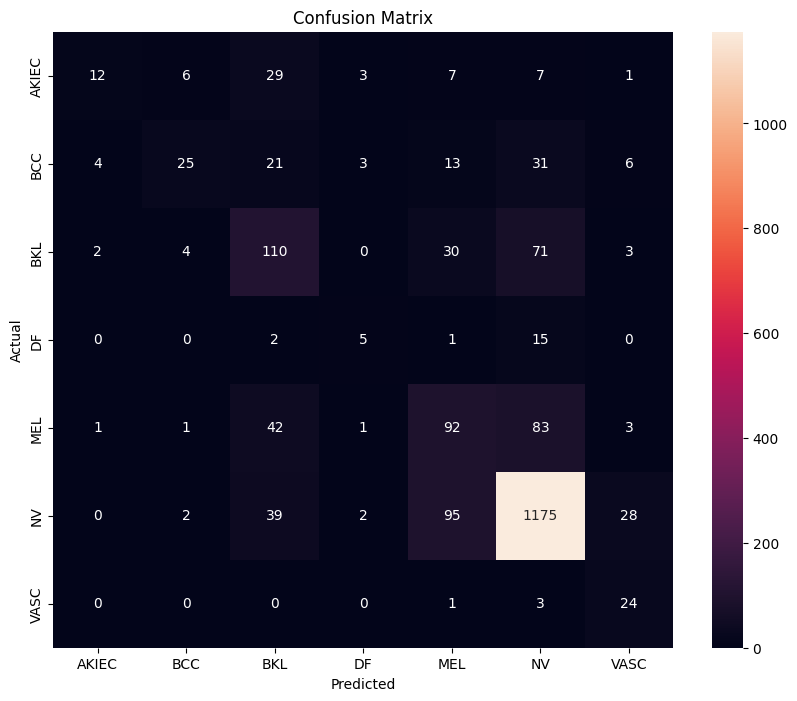

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Report

Title: Skin Cancer Detection Using DL

Dataset size: 10,015 images

Model Architecture: 
- One hot encoding
- train test split
- Initialize random weights
- Image Data Generator
- EfficientNetB0
- model compilation
- model training
- model evaluation

Evaluation Metrics:
   precision    recall  f1-score   support

       AKIEC       0.63      0.18      0.29        65
         BCC       0.66      0.24      0.35       103
         BKL       0.45      0.50      0.48       220
          DF       0.36      0.22      0.27        23
         MEL       0.38      0.41      0.40       223
          NV       0.85      0.88      0.86      1341
        VASC       0.37      0.86      0.52        28

    accuracy                           0.72      2003
   macro avg       0.53      0.47      0.45      2003
weighted avg       0.72      0.72      0.71      2003

Conclusion:The model achieved an overall accuracy of 72% in detecting skin cancer from the given dataset. However, the precision, recall, and f1-score for certain classes such as AKIEC and DF were relatively low, indicating that the model struggled to accurately identify these specific types of skin cancer. The model performed better in identifying the NV class, with a high precision and recall. Overall, while the model shows promise in skin cancer detection, further improvements and fine-tuning may be necessary to enhance its performance, especially for the classes with lower metrics. Future work could involve exploring different model architectures, increasing the dataset size, and implementing techniques to address class imbalance to improve the model's performance across all classes.